<a href="https://colab.research.google.com/github/Sanika-tech123/Advanced-Machine-Learning-Practicals/blob/main/MBA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Groceries_dataset.csv to Groceries_dataset.csv
Number of Itemsets: 126
Number of Rules: 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


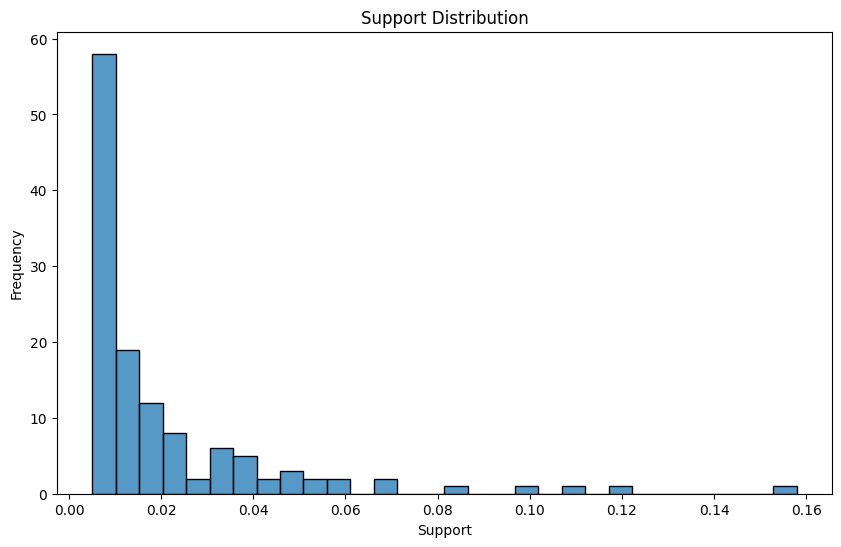

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


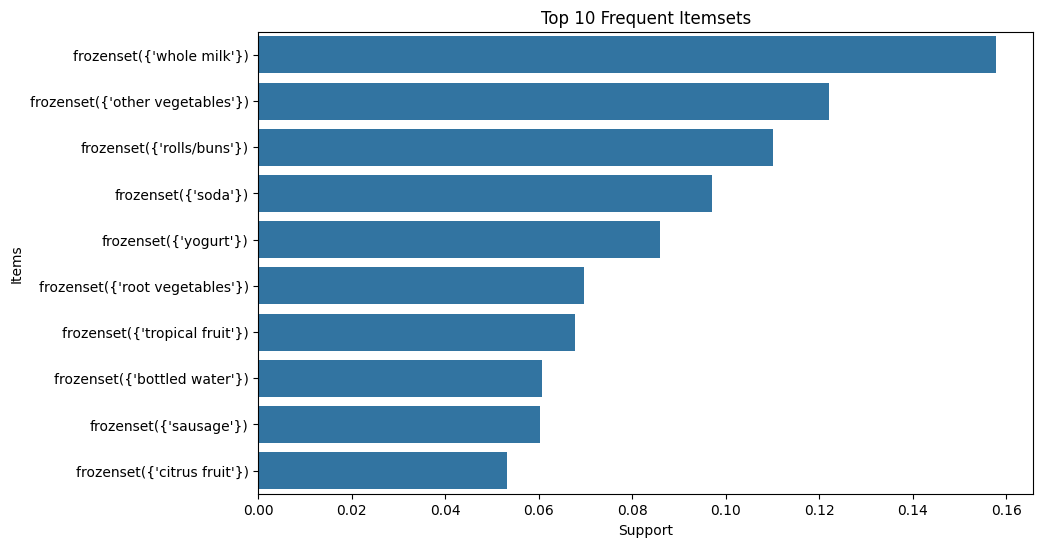


Top Frequent Itemsets:

     support             itemsets  length
0   0.021386           (UHT-milk)       1
1   0.008087      (baking powder)       1
2   0.033950               (beef)       1
3   0.021787            (berries)       1
4   0.016574          (beverages)       1
5   0.045312       (bottled beer)       1
6   0.060683      (bottled water)       1
7   0.037626        (brown bread)       1
8   0.035220             (butter)       1
9   0.017577        (butter milk)       1
10  0.006148           (cake bar)       1
11  0.014369              (candy)       1
12  0.046916        (canned beer)       1
13  0.007686        (canned fish)       1
14  0.005480  (canned vegetables)       1
15  0.011829           (cat food)       1
16  0.012030        (chewing gum)       1
17  0.027869            (chicken)       1
18  0.023592          (chocolate)       1
19  0.053131       (citrus fruit)       1

Top Association Rules:

Empty DataFrame
Columns: [antecedents, consequents, antecedent suppo

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
%matplotlib inline

from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

file_name = list(uploaded.keys())[0]
dataframe = pd.read_csv(file_name)

grouped_data = dataframe.groupby(['Member_number', 'Date'])['itemDescription'].apply(list)
transactions = list(grouped_data)

encoder = TransactionEncoder()
encoded_array = encoder.fit(transactions).transform(transactions)
final_data = pd.DataFrame(encoded_array, columns=encoder.columns_)

itemsets = apriori(final_data, min_support=0.005, use_colnames=True)

rules = association_rules(itemsets, metric="confidence", min_threshold=0.2)
rules = rules[rules['lift'] >= 1]

itemsets['length'] = itemsets['itemsets'].apply(lambda x: len(x))

print("Number of Itemsets:", len(itemsets))
print("Number of Rules:", len(rules))

plt.figure(figsize=(10,6))
sns.histplot(itemsets['support'], bins=30)
plt.title("Support Distribution")
plt.xlabel("Support")
plt.ylabel("Frequency")
plt.show()

if len(rules) > 0:
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=rules['support'], y=rules['confidence'], size=rules['lift'], hue=rules['lift'])
    plt.title("Support vs Confidence")
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.show()

top_products = itemsets.sort_values(by='support', ascending=False).head(10)
top_products['itemsets'] = top_products['itemsets'].astype(str)

plt.figure(figsize=(10,6))
sns.barplot(x='support', y='itemsets', data=top_products)
plt.title("Top 10 Frequent Itemsets")
plt.xlabel("Support")
plt.ylabel("Items")
plt.show()

rules = rules.sort_values(by='lift', ascending=False)

print("\nTop Frequent Itemsets:\n")
print(itemsets.head(20))

print("\nTop Association Rules:\n")
print(rules.head(20))